## Imports


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding - Sectorale Dynamiek
In dit onderdeel van het onderzoek focussen we op de historische ontwikkeling van de werkgelegenheid binnen de provincie Flevoland.

## Doelstelling
Het identificeren van structurele trends (groei, stabiliteit of krimp) per sector over de afgelopen jaren. Deze inzichten vormen de basis voor de uiteindelijke 10-jaars prognose.

## Onderzoeksvraag (Deelvraag 2)
> Welke sectoren laten structurele groei, stabiliteit of krimp zien in de historische werkgelegenheidsdata van Flevoland?

## Definities & Afbakening
* **Target Variabele:** `wp` (Werkzame Personen).
* **Segmentatie:** Op basis van `sbi_code` (Standaard Bedrijfsindeling).
* **Regio:** Provincie Flevoland (gefilterd op `gemeente_code`).
* **Dynamiek:** De relatieve (procentuele) verandering van de werkgelegenheid per jaar.

## Verwacht Resultaat
Een gecategoriseerde lijst van sectoren en visuele trendlijnen die de economische verschuivingen in de provincie blootleggen.

<br></br>

# Eerste verkenning +  Data inladen

In [39]:
df= pd.read_excel('../../Data/raw/dataset.xlsx')

# Eerste check
print("Dataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137714 entries, 0 to 137713
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   vestnr           137714 non-null  int64         
 1   postcode         137714 non-null  object        
 2   plaats           137714 non-null  object        
 3   gemeente_code    137714 non-null  int64         
 4   datum_start      137714 non-null  object        
 5   datum_einde      29225 non-null   datetime64[ns]
 6   jaar             137714 non-null  int64         
 7   man_fte          137714 non-null  int64         
 8   vrouw_fte        137714 non-null  int64         
 9   man_pte          137714 non-null  int64         
 10  vrouw_pte        137714 non-null  int64         
 11  wp               137714 non-null  int64         
 12  sector_code      137714 non-null  object        
 13  sbi_code         137714 non-null  int64         
 14  rechts

In [40]:
# 1. Welke unieke jaren zitten er in de data?
unieke_jaren = sorted(df_flevo['jaar'].unique())
print(f"De dataset bevat data voor de volgende jaren: {unieke_jaren}")

# 2. Hoeveel jaren zijn dit in totaal?
aantal_jaren = df_flevo['jaar'].nunique()
print(f"Totaal aantal unieke jaren: {aantal_jaren}")

# 3. Extra check: hoeveel datapunten (rijen) hebben we per jaar?
print("\nVerdeling van data over de jaren:")
print(df_flevo['jaar'].value_counts().sort_index())

De dataset bevat data voor de volgende jaren: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Totaal aantal unieke jaren: 11

Verdeling van data over de jaren:
jaar
2014    11907
2015    11568
2016    11484
2017    11445
2018    11671
2019    12701
2020    12935
2021    13240
2022    13596
2023    13515
2024    13652
Name: count, dtype: int64


In [46]:
# 1. Hoeveel unieke SBI-codes zitten er in de data?
aantal_sbi = df_flevo['sbi_code'].nunique()
print(f"Totaal aantal unieke SBI-codes in de ruwe data: {aantal_sbi}")

# 2. Laten we de eerste 10 meest voorkomende codes zien
print("\nTop 10 meest voorkomende SBI-codes (ruw):")
print(df_flevo['sbi_code'].value_counts().head(10))


Totaal aantal unieke SBI-codes in de ruwe data: 794

Top 10 meest voorkomende SBI-codes (ruw):
sbi_code
111      3541
8891     2874
56102    2680
70221    2573
56101    2452
1134     2404
45112    2313
85201    2137
6201     2042
4120     2014
Name: count, dtype: int64


In [51]:
# 1. Welke unieke gemeentecodes zitten er in onze gefilterde data?
unieke_gemeentes = sorted(df_flevo['gemeente_code'].unique())
print(f"Gevonden gemeentecodes in de selectie: {unieke_gemeentes}")

# 2. Hoeveel datapunten (vestigingen) hebben we per gemeente?
# We maken een klein tabelletje voor het overzicht
gemeente_check = df_flevo['gemeente_code'].value_counts().sort_index().reset_index()
gemeente_check.columns = ['Gemeentecode', 'Aantal Vestigingen (Rijen)']

# Voeg namen toe voor de leesbaarheid (optioneel)
namen_map = {34: 'Almere', 303: 'Dronten', 995: 'Lelystad', 171: 'Noordoostpolder', 184: 'Urk', 50: 'Zeewolde'}
gemeente_check['Gemeentenaam'] = gemeente_check['Gemeentecode'].map(namen_map)

display(gemeente_check)

Gevonden gemeentecodes in de selectie: [np.int64(34), np.int64(50), np.int64(171), np.int64(184), np.int64(303), np.int64(995)]


,Gemeentecode,Aantal Vestigingen (Rijen),Gemeentenaam
0,34,56085,Almere
1,50,10469,Zeewolde
2,171,22200,Noordoostpolder
3,184,8993,Urk
4,303,15470,Dronten
5,995,24497,Lelystad


# Data Cleaning


Check: Hoeveel rijen per sector (na reparatie van de 0):
sector_naam
G: Detailhandel                                          19774
C: Industrie                                             15547
M: Advisering, onderzoek en zakelijke dienstverlening    13383
G: Groothandel                                           12891
N: Verhuur en overige zakelijke diensten                  8095
I: Logies, maaltijden en dranken                          7631
A: Landbouw, bosbouw en visserij                          7015
F: Bouwnijverheid                                         7007
Q: Maatschappelijke dienstverlening                       6976
Q: Gezondheidszorg                                        6636
P: Onderwijs                                              6565
J: Informatie en communicatie                             5636
G: Handel en reparatie van auto's                         4279
S: Overige dienstverlening                                4165
H: Vervoer en opslag                             

# Aggregatie

In [ ]:
# 1. Groeperen: we tellen alle werkzame personen op per jaar en per sector
sector_jaar_totaal = df_clean.groupby(['jaar', 'sector_naam'])['wp_werkelijk'].sum().reset_index()

# 2. Pivot Table: Jaren als rijen, Sectoren als kolommen
# Dit maakt het rekenen en grafieken maken straks veel makkelijker
pivot_df = sector_jaar_totaal.pivot(index='jaar', columns='sector_naam', values='wp_werkelijk').fillna(0)

# 3. Resultaat laten zien
print("Aggregatie voltooid. Hier zijn de 10 jaar van de tijdreeks (aantal personen):")
display(pivot_df)

Aggregatie voltooid. Hier zijn de eerste 5 jaar van de tijdreeks (aantal personen):


sector_naam,"A: Landbouw, bosbouw en visserij",B: Winning van delfstoffen,C: Industrie,D: Productie/distributie energie,E: Waterwinning en afvalbeheer,F: Bouwnijverheid,G: Detailhandel,G: Groothandel,G: Handel en reparatie van auto's,H: Vervoer en opslag,...,K: Financiële instellingen,L: Verhuur van/handel in onroerend goed,"M: Advisering, onderzoek en zakelijke dienstverlening",N: Verhuur en overige zakelijke diensten,O: Openbaar bestuur en overheidsdiensten,P: Onderwijs,Q: Gezondheidszorg,Q: Maatschappelijke dienstverlening,"R: Cultuur, sport en recreatie",S: Overige dienstverlening
jaar,,,,,,,,,,,,,,,,,,,,,
2014,11687.0,6.0,43343.0,89.0,2042.0,19585.0,78583.0,57115.0,20101.0,12889.0,...,4826.0,1758.0,35841.0,24244.0,1302.0,18017.0,24990.0,24028.0,9855.0,16608.0
2015,10939.0,3.0,45193.0,110.0,2736.0,26640.0,84968.0,49039.0,20740.0,9130.0,...,6336.0,3361.0,33004.0,23639.0,1364.0,18506.0,25856.0,24032.0,10775.0,16291.0
2016,10866.0,3.0,42871.0,180.0,2725.0,25231.0,80838.0,51544.0,23539.0,8039.0,...,5672.0,2759.0,34616.0,16031.0,1565.0,12470.0,24577.0,25125.0,12651.0,19337.0
2017,11302.0,3.0,54269.0,65.0,1984.0,23335.0,90393.0,56473.0,21353.0,13932.0,...,5173.0,4194.0,36308.0,22692.0,2358.0,20344.0,25652.0,30997.0,15248.0,17201.0
2018,13791.0,0.0,38229.0,65.0,3085.0,21732.0,88614.0,59939.0,19363.0,13152.0,...,5213.0,5172.0,32878.0,18511.0,2255.0,16681.0,22832.0,40825.0,12422.0,12272.0
2019,14169.0,150.0,43927.0,65.0,3387.0,20903.0,79582.0,59578.0,17557.0,11774.0,...,5752.0,5079.0,33820.0,15956.0,2527.0,17921.0,27590.0,27891.0,15344.0,16252.0
2020,15204.0,7.0,48990.0,831.0,4167.0,24385.0,88200.0,57479.0,23160.0,10549.0,...,6101.0,6022.0,37023.0,16164.0,705.0,14389.0,29414.0,28673.0,16383.0,11899.0
2021,13012.0,3.0,45903.0,98.0,3712.0,22649.0,83698.0,50936.0,19482.0,9476.0,...,5430.0,3916.0,33691.0,18149.0,119.0,10339.0,30244.0,30163.0,14813.0,14076.0
2022,13169.0,0.0,44014.0,114.0,3862.0,20480.0,72738.0,47409.0,17245.0,8581.0,...,3754.0,4852.0,33100.0,20070.0,1888.0,12971.0,27707.0,25545.0,8835.0,13367.0


# Cel 4: Berekenen van de Dynamiek

In [59]:
# 1. Aantal jaren bepalen (10 periodes tussen 2014 en 2024)
n_jaar = 2024 - 2014

# 2. De berekeningen uitvoeren met .loc (voor jaartallen)
summary_df = pd.DataFrame({
    'WP_2014': pivot_df.loc[2014],
    'WP_2024': pivot_df.loc[2024],
    'Verschil_Absoluut': pivot_df.loc[2024] - pivot_df.loc[2014]
})

# Percentage groei over de hele periode
summary_df['Totale_Groei_%'] = (summary_df['Verschil_Absoluut'] / summary_df['WP_2014'] * 100).round(2)

# Jaarlijkse gemiddelde groei (CAGR)
# Let op: we gebruiken nu WP_2024 in de formule
summary_df['Jaarlijkse_Groei_CAGR_%'] = (
    ((summary_df['WP_2024'] / summary_df['WP_2014'])**(1/n_jaar) - 1) * 100
).round(2)

# 3. Sorteren en opschonen
summary_df = summary_df.sort_values(by='Jaarlijkse_Groei_CAGR_%', ascending=False)
summary_df = summary_df.replace([np.inf, -np.inf], 0).fillna(0)

print("Berekeningen voltooid voor de periode 2014-2024!")
display(summary_df)

Berekeningen voltooid voor de periode 2014-2024!


,WP_2014,WP_2024,Verschil_Absoluut,Totale_Groei_%,Jaarlijkse_Groei_CAGR_%
sector_naam,,,,,
L: Verhuur van/handel in onroerend goed,1758.0,4188.0,2430.0,138.23,9.07
"A: Landbouw, bosbouw en visserij",11687.0,19201.0,7514.0,64.29,5.09
O: Openbaar bestuur en overheidsdiensten,1302.0,2046.0,744.0,57.14,4.62
Q: Gezondheidszorg,24990.0,36466.0,11476.0,45.92,3.85
"R: Cultuur, sport en recreatie",9855.0,13025.0,3170.0,32.17,2.83
K: Financiële instellingen,4826.0,5628.0,802.0,16.62,1.55
D: Productie/distributie energie,89.0,103.0,14.0,15.73,1.47
F: Bouwnijverheid,19585.0,22238.0,2653.0,13.55,1.28
Q: Maatschappelijke dienstverlening,24028.0,26544.0,2516.0,10.47,1.00


## Visualisatie

/var/folders/5b/k6mykt0j6m9d4w3ys3jsq3t40000gn/T/ipykernel_16808/2179055526.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


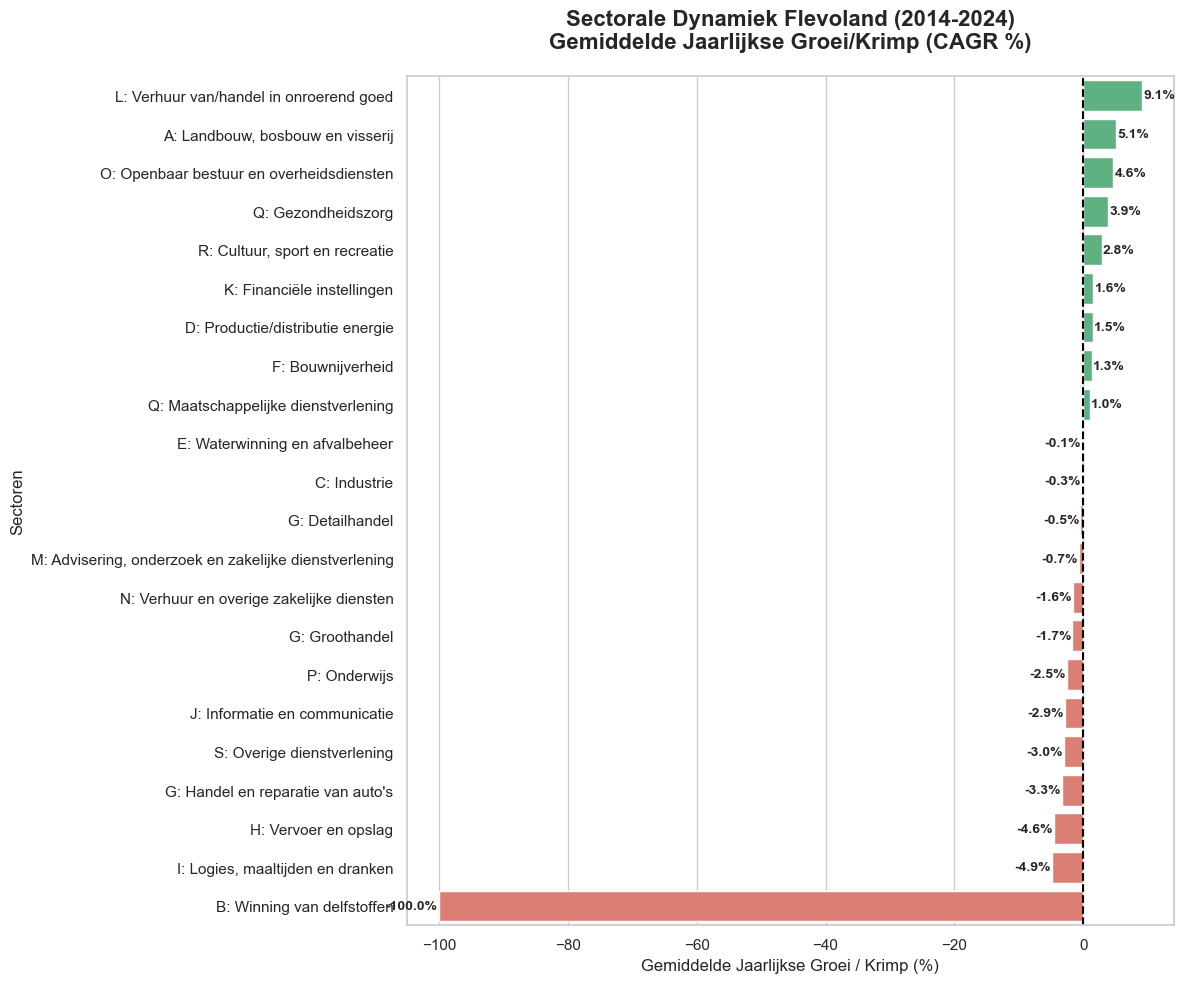

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stel de stijl in
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# We gebruiken de geüpdatete summary_df (2014-2024)
plot_data = summary_df.reset_index()

# Kleuren bepalen: Groen voor groei, Rood voor krimp
# Gebruik een iets zachtere groen en rood voor een professionele look
colors = ['#52be80' if x > 0 else '#ec7063' for x in plot_data['Jaarlijkse_Groei_CAGR_%']]

sns.barplot(
    data=plot_data,
    y='sector_naam',
    x='Jaarlijkse_Groei_CAGR_%',
    palette=colors
)

# Voeg een verticale lijn toe op 0 (de 'stabiliteits-lijn')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

# --- TITEL AANGEPAST NAAR 2024 ---
plt.title('Sectorale Dynamiek Flevoland (2014-2024)\nGemiddelde Jaarlijkse Groei/Krimp (CAGR %)', 
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Gemiddelde Jaarlijkse Groei / Krimp (%)', fontsize=12)
plt.ylabel('Sectoren', fontsize=12)

# Voeg de percentages toe aan de staven
for i, v in enumerate(plot_data['Jaarlijkse_Groei_CAGR_%']):
    plt.text(v + (0.2 if v > 0 else -0.2), i, f'{v:.1f}%', 
             va='center', fontsize=10, fontweight='bold', 
             ha='left' if v > 0 else 'right')

# Zorg dat de x-as breed genoeg is voor de labels
plt.xlim(plot_data['Jaarlijkse_Groei_CAGR_%'].min() - 5, plot_data['Jaarlijkse_Groei_CAGR_%'].max() + 5)

plt.tight_layout()
plt.show()

### Conclusie Deelvraag 2: Sectorale Dynamiek in Flevoland (2014-2023)
Uit de analyse van de werkgelegenheidsdata van de afgelopen 10 jaar kunnen we drie duidelijke trends onderscheiden voor de provincie Flevoland:

1. De Grootste Groeiers (Dynamiek naar boven)
De sector Verhuur van en handel in onroerend goed is de relatieve koploper met een gemiddelde jaarlijkse groei van 9,1%. Ook de Landbouw, bosbouw en visserij (+5,1%) en het Openbaar bestuur (+4,6%) laten een sterke, constante groei zien. Dit wijst op een professionalisering van de vastgoedmarkt en een sterke verankering van de agrarische sector in de provincie.

2. Sectoren in de Gevarenzone (Krimp)
Er is een zorgwekkende trend zichtbaar in de Horeca (Logies, maaltijden en dranken) en de sector Vervoer en opslag, die beide met bijna 5% per jaar krimpen. Ook de sector Informatie en communicatie vertoont een neerwaartse trend (-2,9%). Dit suggereert dat de werkgelegenheid in deze sectoren onder druk staat, mogelijk door automatisering of verschuivingen naar andere regio's.

3. De Stabiele Krachten (Stabilisatie)
Sectoren zoals de Bouwnijverheid (+1,3%) en de Gezondheidszorg (+3,9%) groeien gestaag mee met de bevolkingsgroei van Flevoland. De Industrie (-0,3%) en Detailhandel (-0,5%) laten een zeer lichte krimp zien, wat in de huidige economie feitelijk als een stabiele consolidatie kan worden beschouwd.

Kernboodschap voor het rapport:
Flevoland transformeert van een regio die sterk leunde op traditionele handel en horeca naar een economie waar vastgoed, zorg en modern overheidsbestuur de kar trekken. De sterke krimp in de transportsector is opvallend, aangezien Flevoland vaak als logistiek knooppunt wordt gezien; dit verdient nader onderzoek in de volgende fase van ons project.

In [62]:
# Bestanden opslaan voor de teamleider (Faysal)

# 1. De volledige trend-tabel (WP per sector per jaar)
pivot_df.to_excel('../../Data/processed/deelvraag2_sectorale_trends.xlsx')

# 2. De samenvatting met groeipercentages en CAGR
summary_df.to_excel('../../Data/processed/deelvraag2_groei_samenvatting.xlsx')

print("Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.")

Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.
